In [43]:
# Se cargan las bibliotecas de pandas, numpy y matplotlib
import pandas as pd
from pandas import ExcelWriter
from pandas import ExcelFile
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import stats
from scipy.stats import anderson, normaltest, probplot, t
import time

print("Bibliotecas importadas correctamente")

Bibliotecas importadas correctamente


In [44]:
#Funcion para cargar archivo de datos modulados

def leer_archivo (dir_archivo):

    # Direccion del archivo CSV
    archivo_csv = dir_archivo
    
    # Cargar el archivo CSV en un DataFrame de Pandas
    datos = pd.read_csv(archivo_csv, header=None)
    
    # Cambiar la letra i por j en cada dato y lo convierte en complejo
    datos[0] = datos[0].str.replace('i', 'j')
    datos[0] = datos[0].apply(lambda x: complex(x))
    
    return datos

In [45]:
#Genera muestras de ruido AWGN con media cero y desviación estándar de uno

PI = 3.1415

def AWGN_generator():
    
    temp2 = np.random.rand()
    temp1 = np.cos(2.0 * PI * np.random.rand())
    result = math.sqrt(-2.0 * math.log(temp2)) * temp1

    # Escala el resultado al rango [-1, 1]
    result = np.clip(result, -1, 1)
    
    return result

In [46]:
#Funcion para agregar el ruido AWGN a los datos de salida del modulador

def agregar_ruido(datos):
    for indice_fila, fila in datos.iterrows():
        for indice_elemento, elemento in enumerate(fila):
            parte_real, parte_imaginaria = np.real(elemento), np.imag(elemento)
            ruido_real, ruido_imaginario = AWGN_generator(), AWGN_generator()
            datos.iloc[indice_fila, indice_elemento] = parte_real + ruido_real + 1j * (parte_imaginaria + ruido_imaginario)
    return datos

In [47]:
#Funcion para simular la multitrayectoria del canal

def multipath(datos, num_caminos=3, retraso_max=5):
    datos_multipath = datos.copy()
    num_filas = datos.shape[0]
    
    for indice_fila, fila in datos.iterrows():
        multipath_signal = np.zeros_like(fila, dtype=complex)
        for _ in range(num_caminos):
            retraso = np.random.randint(0, retraso_max)
            ganancia = np.random.uniform(0.5, 1.0)
            multipath_signal += np.roll(fila, retraso) * ganancia
        datos_multipath.iloc[indice_fila] = multipath_signal
    
    return datos_multipath

In [48]:
#Funciones de graficas

def graficar_real(datos, titulo):
    datos = datos.head(250)
    magnitudes = np.abs(datos[0])  # Calcula las magnitudes de los números complejos
    fases = np.angle(datos[0])  # Calcula las fases de los números complejos
    cosenos_fase = np.cos(fases)  # Calcula el coseno de las fases
    
    # Multiplica la magnitud por el coseno de la fase
    magnitud_por_cos_fase = magnitudes * cosenos_fase
    
    # Grafica la magnitud por el coseno de la fase
    plt.plot(magnitud_por_cos_fase)
    plt.title(titulo)
    plt.xlabel('Tiempo')
    plt.ylabel('Magnitud')
    plt.show()


def graficar_multipath_real(datos, datos_multipath):
    plt.figure(figsize=(10, 6))
    plt.plot(np.real(datos[0]), label='Original (Parte Real)', color='blue')
    plt.plot(np.real(datos_multipath[0]), label='Multipath (Parte Real)', color='red')
    plt.title('Señal con Efecto Multipath (Parte Real)')
    plt.xlabel('Muestras')
    plt.ylabel('Amplitud')
    plt.legend()
    plt.grid(True)
    plt.show()

In [49]:
# Funcion "main" para simular el canal para hamming (7,4) y hamming (15,11)
def simular_canal(ruta_entrada, ruta_salida, titulo):
   
    data_frame = leer_archivo(hammig_15_11)

    graficar_real(data_frame, f"{titulo} - Sin ruido") # Grafica datos sin ruido
    
    datos_con_ruido = agregar_ruido(data_frame) 
    graficar_real(datos_con_ruido, f"{titulo} - Con ruido") # Grafica datos con ruido

    datos_multipath = multipath(data_frame) #Agrega multiplth
    graficar_real(datos_multipath, f"{titulo} - Multipath")

    #Datos de salida
    datos_con_ruido[0] = datos_con_ruido[0].apply(lambda x: str(x))
    datos_con_ruido[0] = datos_con_ruido[0].str.replace('j', 'i')
    datos_con_ruido.to_csv(ruta_salida, index=False, header=None)

    
    # Calcular capacidad del canal
    B = 2e6   
    SNR = 10  
    capacidad_canal = B * np.log2(1 + SNR)
    print(f"Capacidad del canal: {capacidad_canal:.2f} bps")
    
    # Velocidad de transferencia del nRF52832
    velocidad_transferencia = 1e6  # 1 Mbps
    
    # Analizar saturación del canal
    if velocidad_transferencia > capacidad_canal:
        print(f"El canal se satura. Capacidad del canal: {capacidad_canal:.2f} bps, Velocidad de transferencia: {velocidad_transferencia:.2f} bps")
    else:
        print(f"El canal no se satura. Capacidad del canal: {capacidad_canal:.2f} bps, Velocidad de transferencia: {velocidad_transferencia:.2f} bps")

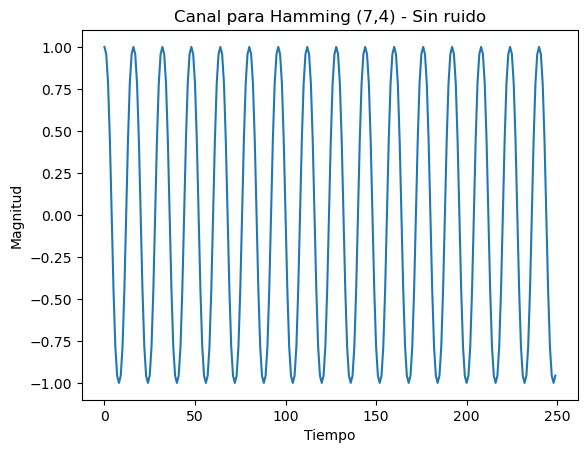

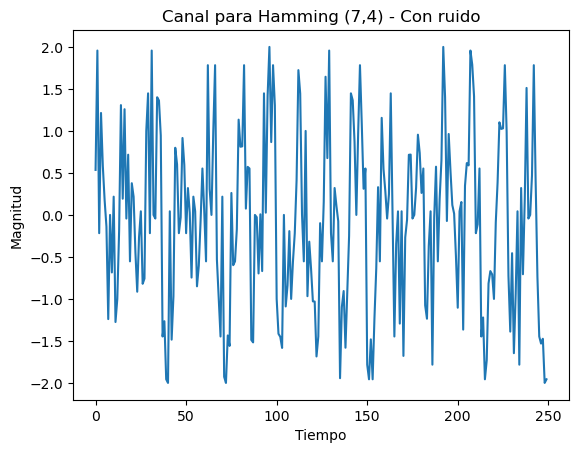

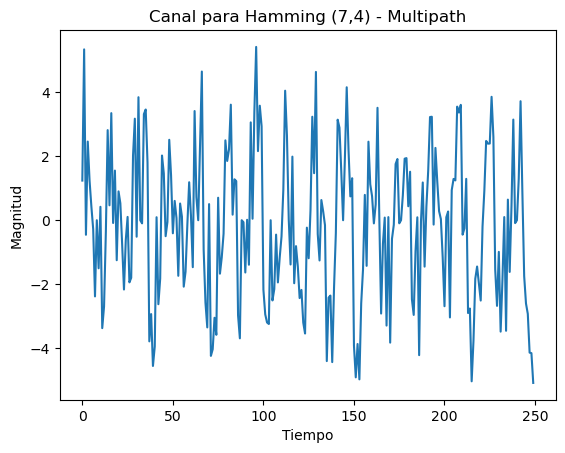

Capacidad del canal: 6918863.24 bps
El canal no se satura. Capacidad del canal: 6918863.24 bps, Velocidad de transferencia: 1000000.00 bps


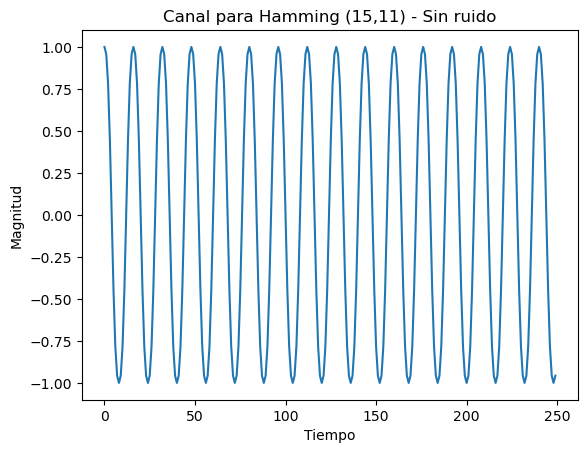

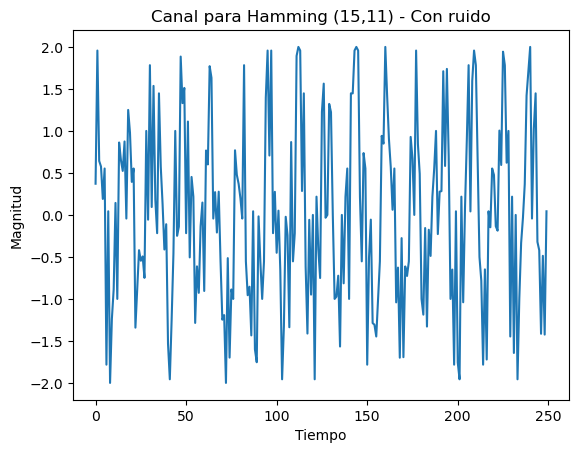

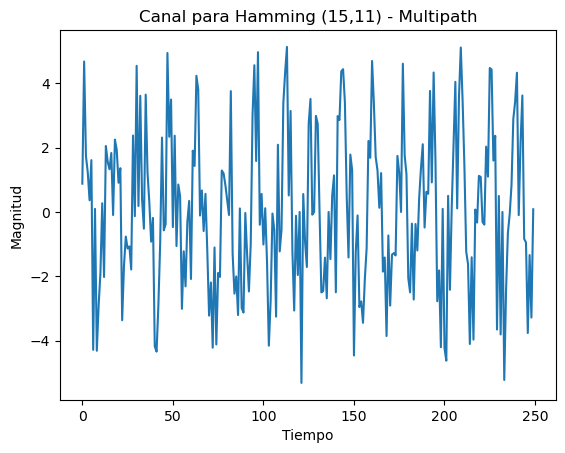

Capacidad del canal: 6918863.24 bps
El canal no se satura. Capacidad del canal: 6918863.24 bps, Velocidad de transferencia: 1000000.00 bps


In [50]:
#Llamar a la funcion principal
simular_canal(
    ruta_entrada="Datos_modulados/modulado_hamming_7_4.txt",
    ruta_salida="Datos_canal/salida_canal_7_4.txt",
    titulo="Canal para Hamming (7,4)"
)

simular_canal(
    ruta_entrada="Datos_modulados/modulado_hamming_15_11.txt",
    ruta_salida="Datos_canal/salida_canal_15_11.txt",
    titulo="Canal para Hamming (15,11)"
)